**Binary Classification**

In this folder the goal is to make binary classification for next day.

In this file we will use the sentiments of older pipeline that preprocessed the news data.

The architecture of the pipeline is suspicious that can cause loss of information.

If the classification results are bad new pipeline will be builded. 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
path = '../last-1/datasets/mega_dataset.csv'
df = pd.read_csv(path, parse_dates=['Date'])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
0,2023-01-03,0.279186,0.614588,0.722545,0.810606,0.351997,0.528008,0.411833,2,0
1,2023-01-04,0.292612,0.614588,0.722545,0.810606,0.374767,0.520214,0.419316,2,1
2,2023-01-05,0.274683,0.614588,0.722545,0.810606,0.338186,0.495860,0.407670,2,-1
3,2023-01-06,0.301284,0.614588,0.722545,0.810606,0.374393,0.521676,0.430246,2,1
4,2023-01-09,0.304536,0.614588,0.722545,0.810606,0.426652,0.512908,0.429469,0,1


In [17]:
df.columns

Index(['Date', 'Gold_Price', 'Crude_Oil', 'Inflation', 'Interest_Rate',
       'USD_EUR', 'SLV', '^GSPC', 'sent_enc', 'increase_ind'],
      dtype='object')

In [18]:
drop = ['Crude_Oil', 'Inflation', 'Interest_Rate',
       'USD_EUR', 'SLV', '^GSPC']

df = df.drop(columns=drop)
df.head()

,Date,Gold_Price,sent_enc,increase_ind
0,2023-01-03,0.279186,2,0
1,2023-01-04,0.292612,2,1
2,2023-01-05,0.274683,2,-1
3,2023-01-06,0.301284,2,1
4,2023-01-09,0.304536,0,1


In [19]:
df['sent_enc'].value_counts()

sent_enc
2    263
1    126
0    112
Name: count, dtype: int64

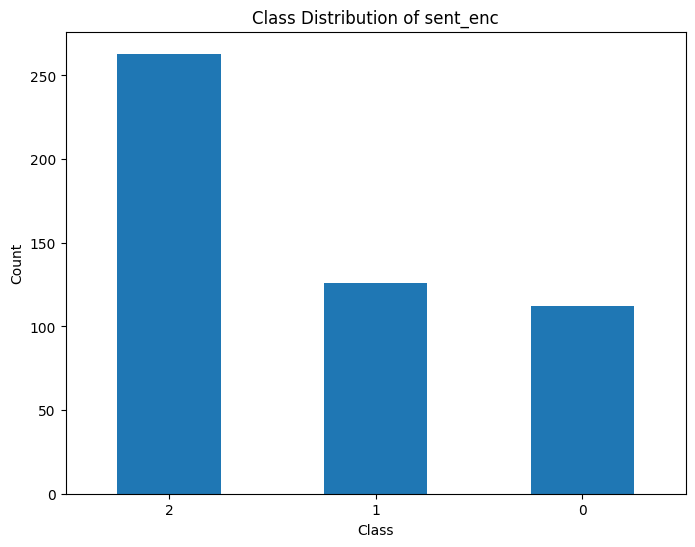

In [20]:
class_counts = df['sent_enc'].value_counts()


plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')

plt.title("Class Distribution of sent_enc")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [25]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.query("Date >= '2024-01-01'")

In [26]:
print(df.head())
print(df.tail())

          Date  Gold_Price  sent_enc  increase_ind
249 2024-01-02    0.443129         0            -1
250 2024-01-03    0.429870         0            -1
251 2024-01-04    0.431454         0             1
252 2024-01-05    0.431705         0             1
253 2024-01-08    0.419363         1            -1
          Date  Gold_Price  sent_enc  increase_ind
496 2024-12-24    0.866077         0             1
497 2024-12-26    0.879670         2             1
498 2024-12-27    0.865744         1            -1
499 2024-12-30    0.859323         2            -1
500 2024-12-31    0.871831         2             1


In [27]:
path = 'dataset/dataset.csv'
df.to_csv(path, index=False)

**Convulution**

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [29]:
X = df[['sent_enc']].values
y = df['increase_ind'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for Conv1D: (samples, timesteps, features)
# Here each sample has timesteps=1, features=1
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Build CNN model
model = Sequential([
    Conv1D(filters=16, kernel_size=1, activation='relu', input_shape=(1,1)),
    Dropout(0.2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='tanh')  # because target is -1 / 1
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',         # for regression to -1/1
    metrics=['accuracy'] # to check classification accuracy
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=2
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.3f}")

c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
10/10 - 2s - 166ms/step - accuracy: 0.0000e+00 - loss: 1.1442 - val_accuracy: 0.0000e+00 - val_loss: 1.1383
Epoch 2/50
10/10 - 0s - 11ms/step - accuracy: 0.0000e+00 - loss: 1.0933 - val_accuracy: 0.0000e+00 - val_loss: 1.0804
Epoch 3/50
10/10 - 0s - 10ms/step - accuracy: 0.0000e+00 - loss: 1.0737 - val_accuracy: 0.0000e+00 - val_loss: 1.0369
Epoch 4/50
10/10 - 0s - 9ms/step - accuracy: 0.0000e+00 - loss: 1.0544 - val_accuracy: 0.0000e+00 - val_loss: 1.0180
Epoch 5/50
10/10 - 0s - 10ms/step - accuracy: 0.0000e+00 - loss: 1.0341 - val_accuracy: 0.0000e+00 - val_loss: 1.0012
Epoch 6/50
10/10 - 0s - 11ms/step - accuracy: 0.0000e+00 - loss: 1.0203 - val_accuracy: 0.0000e+00 - val_loss: 0.9941
Epoch 7/50
10/10 - 0s - 12ms/step - accuracy: 0.0000e+00 - loss: 1.0027 - val_accuracy: 0.0000e+00 - val_loss: 0.9887
Epoch 8/50
10/10 - 0s - 13ms/step - accuracy: 0.0000e+00 - loss: 0.9958 - val_accuracy: 0.0000e+00 - val_loss: 0.9808
Epoch 9/50
10/10 - 0s - 10ms/step - accuracy: 0.0000e+00

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


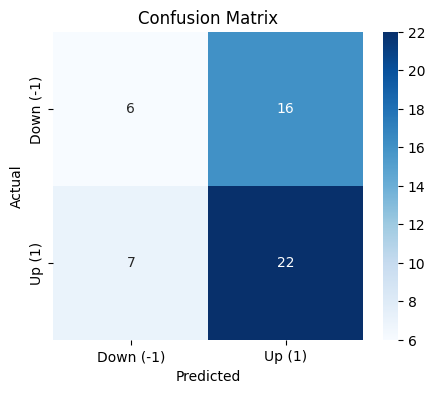

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.46      0.27      0.34        22
      Up (1)       0.58      0.76      0.66        29

    accuracy                           0.55        51
   macro avg       0.52      0.52      0.50        51
weighted avg       0.53      0.55      0.52        51



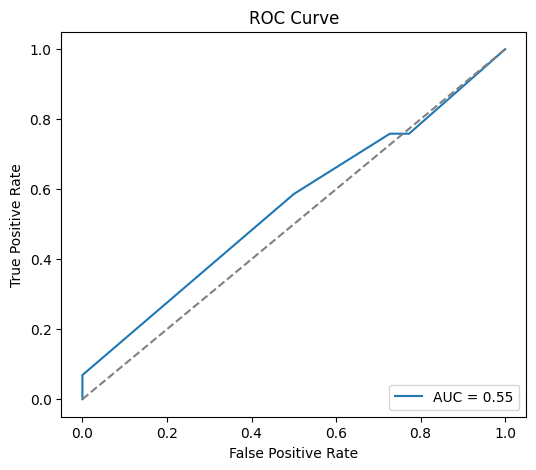

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# === Predictions ===
# If you kept y in {-1, 1}, convert to {0,1} for classification metrics
y_test_class = (y_test == 1).astype(int)

# Get predicted probabilities
y_pred_probs = model.predict(X_test).ravel()

# Convert to class predictions
y_pred_class = (y_pred_probs > 0).astype(int)  # threshold at 0 because tanh outputs [-1,1]

# === Confusion Matrix ===
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down (-1)", "Up (1)"],
            yticklabels=["Down (-1)", "Up (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# === Classification Report ===
print("Classification Report:")
print(classification_report(y_test_class, y_pred_class, target_names=["Down (-1)", "Up (1)"]))

# === ROC Curve ===
fpr, tpr, thresholds = roc_curve(y_test_class, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [31]:
y = (df['increase_ind'] == 1).astype(int).values
X = df[['sent_enc']].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for Conv1D: (samples, timesteps=1, features=1)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, 1))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ==== Model ====
model = Sequential([
    Conv1D(filters=16, kernel_size=1, activation='relu', input_shape=(1,1)),
    Dropout(0.2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')   # sigmoid for binary classification
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==== Train ====
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=2
)

# ==== Evaluate ====
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.3f}")

Epoch 1/50


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 - 1s - 107ms/step - accuracy: 0.5000 - loss: 0.7009 - val_accuracy: 0.5610 - val_loss: 0.6744
Epoch 2/50
10/10 - 0s - 10ms/step - accuracy: 0.4250 - loss: 0.6999 - val_accuracy: 0.7073 - val_loss: 0.6780
Epoch 3/50
10/10 - 0s - 11ms/step - accuracy: 0.5063 - loss: 0.6978 - val_accuracy: 0.7073 - val_loss: 0.6804
Epoch 4/50
10/10 - 0s - 10ms/step - accuracy: 0.4938 - loss: 0.6957 - val_accuracy: 0.7073 - val_loss: 0.6816
Epoch 5/50
10/10 - 0s - 10ms/step - accuracy: 0.5437 - loss: 0.6950 - val_accuracy: 0.7073 - val_loss: 0.6830
Epoch 6/50
10/10 - 0s - 10ms/step - accuracy: 0.5063 - loss: 0.6960 - val_accuracy: 0.7073 - val_loss: 0.6845
Epoch 7/50
10/10 - 0s - 10ms/step - accuracy: 0.5375 - loss: 0.6942 - val_accuracy: 0.7073 - val_loss: 0.6844
Epoch 8/50
10/10 - 0s - 10ms/step - accuracy: 0.5188 - loss: 0.6919 - val_accuracy: 0.5854 - val_loss: 0.6862
Epoch 9/50
10/10 - 0s - 10ms/step - accuracy: 0.5312 - loss: 0.6898 - val_accuracy: 0.4390 - val_loss: 0.6885
Epoch 10/50
10/10 - 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


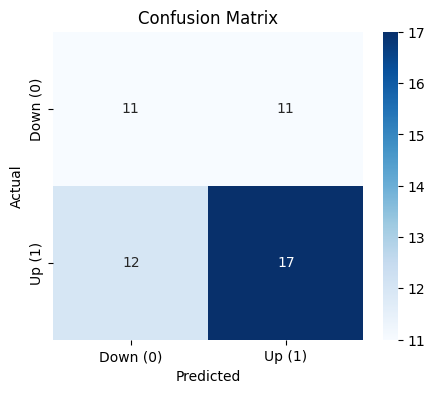

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.48      0.50      0.49        22
      Up (1)       0.61      0.59      0.60        29

    accuracy                           0.55        51
   macro avg       0.54      0.54      0.54        51
weighted avg       0.55      0.55      0.55        51



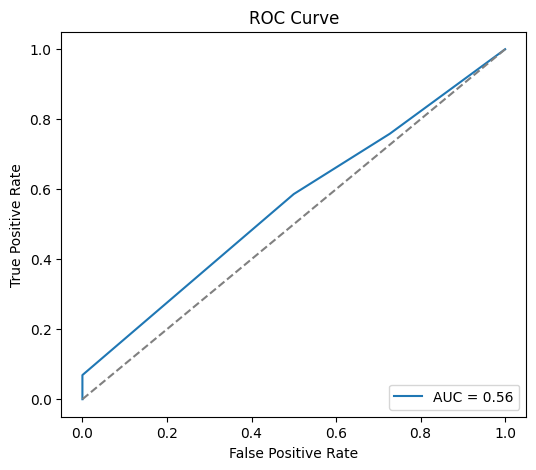

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# === Predictions ===
y_pred_probs = model.predict(X_test).ravel()
y_pred_class = (y_pred_probs > 0.5).astype(int)

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down (0)", "Up (1)"],
            yticklabels=["Down (0)", "Up (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# === Classification Report ===
print("Classification Report:")
print(classification_report(y_test, y_pred_class, target_names=["Down (0)", "Up (1)"]))

# === ROC Curve ===
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()